# 🚗 Vehicle Fuel Efficiency Prediction
## Notebook 7: Model Evaluation

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
df = pd.read_csv('../data/auto-mpg-features.csv')
TARGET = 'mpg'
FEATURE_COLS = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'power_to_weight', 'displacement_per_cyl', 'log_weight', 'log_displacement', 'log_horsepower', 'weight_class_enc', 'era_enc', 'origin_2', 'origin_3']
X = df[FEATURE_COLS]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
best_rf = joblib.load('../models/random_forest_best.pkl')
best_gb = joblib.load('../models/gradient_boosting_best.pkl')
print('Setup complete ✓')

Setup complete ✓


## 7.1 Test Set Evaluation

In [4]:
def evaluate_model(model, name, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    return {
        'Model': name,
        'Train R²':  r2_score(y_train, y_train_pred),
        'Test R²':   r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE':  np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE':  mean_absolute_error(y_train, y_train_pred),
        'Test MAE':   mean_absolute_error(y_test, y_test_pred),
        'Overfit Gap': r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred),
        'y_pred': y_test_pred
    }
eval_rf = evaluate_model(best_rf, 'Random Forest', X_train, X_test, y_train, y_test)
eval_gb = evaluate_model(best_gb, 'Gradient Boosting', X_train, X_test, y_train, y_test)
eval_df = pd.DataFrame([eval_rf, eval_gb]).drop(columns=['y_pred'])
eval_df = eval_df.set_index('Model').round(4)
display(eval_df)
best_model_name = eval_df['Test R²'].idxmax()
best_model      = best_rf if best_model_name == 'Random Forest' else best_gb
best_pred       = eval_rf['y_pred'] if best_model_name == 'Random Forest' else eval_gb['y_pred']
print(f'\n✅ Best Model: {best_model_name}')

,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE,Overfit Gap
Model,,,,,,,
Random Forest,0.9812,0.9063,1.0863,2.2446,0.7550,1.6521,0.0749
Gradient Boosting,0.9766,0.9110,1.2121,2.1880,0.9321,1.6186,0.0656



✅ Best Model: Gradient Boosting


## 7.2 Actual vs Predicted Plot

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, eval_res, color in zip(axes, [eval_rf, eval_gb], ['#3498db', '#2ecc71']):
    y_pred = eval_res['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.6, color=color, s=40, edgecolors='white', linewidths=0.3)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
    r2  = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_title(f"{eval_res['Model']}\nR²={r2:.4f} | RMSE={rmse:.4f}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual MPG')
    ax.set_ylabel('Predicted MPG')
    ax.legend()
plt.suptitle('Actual vs Predicted MPG', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/11_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1600x600 with 2 Axes>

## 7.3 Residual Analysis

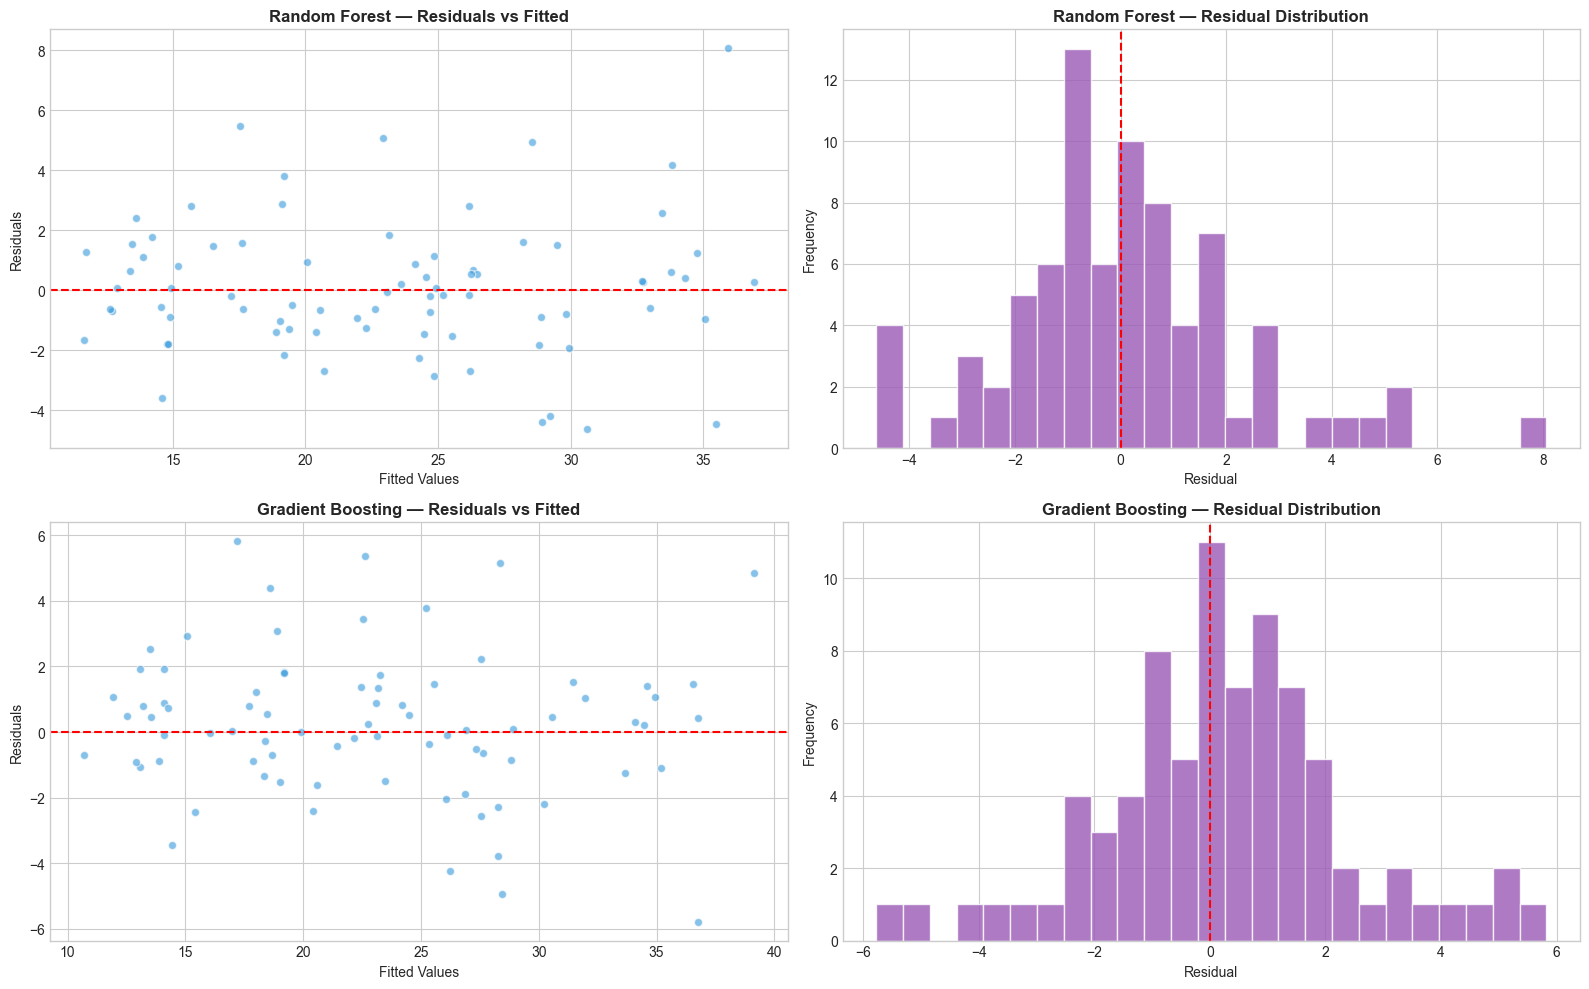

In [6]:
residuals_rf = y_test.values - eval_rf['y_pred']
residuals_gb = y_test.values - eval_gb['y_pred']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, (name, residuals, preds) in enumerate([
    ('Random Forest',    residuals_rf, eval_rf['y_pred']),
    ('Gradient Boosting', residuals_gb, eval_gb['y_pred'])
]):
    axes[i][0].scatter(preds, residuals, alpha=0.6, s=35, color='#3498db', edgecolors='white')
    axes[i][0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i][0].set_title(f'{name} — Residuals vs Fitted', fontweight='bold')
    axes[i][0].set_xlabel('Fitted Values')
    axes[i][0].set_ylabel('Residuals')
    axes[i][1].hist(residuals, bins=25, color='#9b59b6', edgecolor='white', alpha=0.8)
    axes[i][1].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i][1].set_title(f'{name} — Residual Distribution', fontweight='bold')
    axes[i][1].set_xlabel('Residual')
    axes[i][1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('../plots/12_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.4 Feature Importance

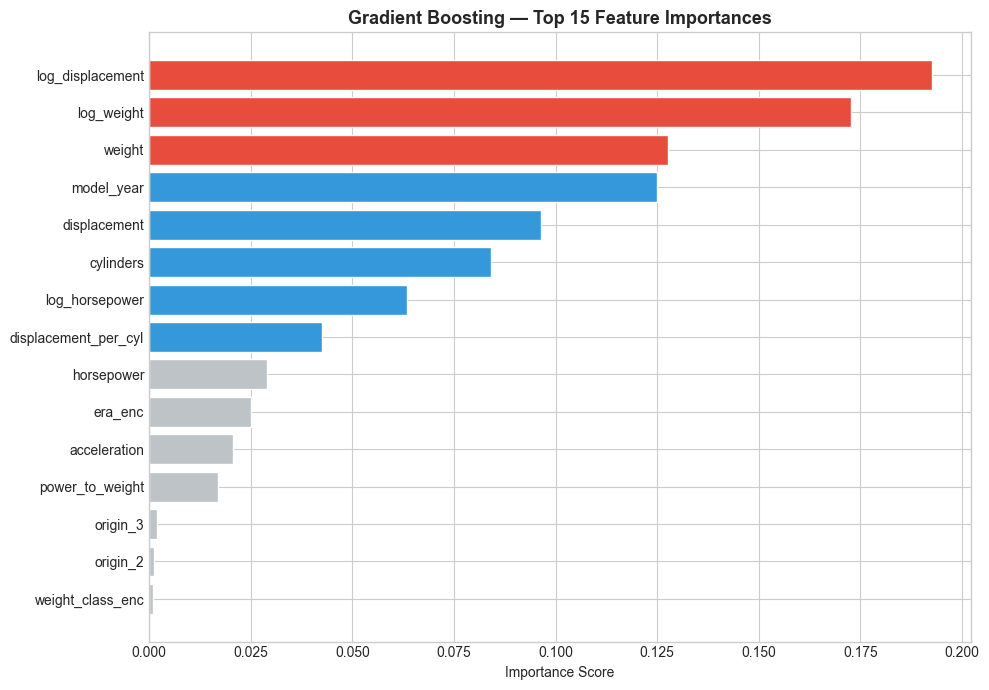

Top 15 Features:
log_displacement        0.192484
log_weight              0.172580
weight                  0.127681
model_year              0.124851
displacement            0.096428
cylinders               0.084214
log_horsepower          0.063368
displacement_per_cyl    0.042501
horsepower              0.028924
era_enc                 0.024971
acceleration            0.020718
power_to_weight         0.017003
origin_3                0.002006
origin_2                0.001325
weight_class_enc        0.000946


In [7]:
fi = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top_fi = fi.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if i < 3 else '#3498db' if i < 8 else '#bdc3c7' for i in range(len(top_fi))]
ax.barh(top_fi.index[::-1], top_fi.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title(f'{best_model_name} — Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../plots/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 15 Features:')
print(top_fi.to_string())

## 7.5 Learning Curves

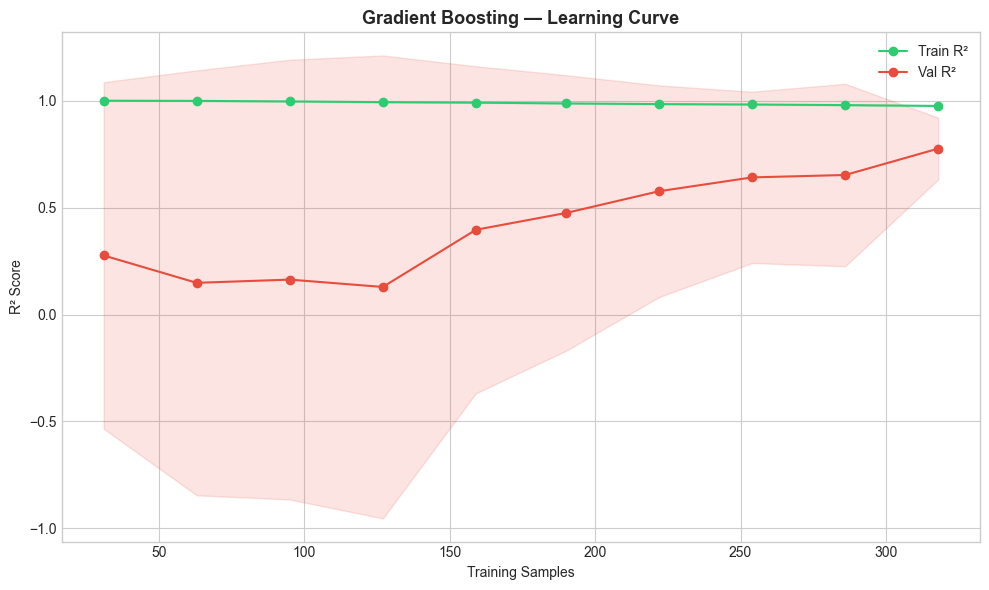

In [8]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#2ecc71', label='Train R²')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='#2ecc71')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#e74c3c', label='Val R²')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='#e74c3c')
ax.set_title(f'{best_model_name} — Learning Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Training Samples')
ax.set_ylabel('R² Score')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/14_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.6 Summary Table

In [9]:
print('=== FINAL MODEL EVALUATION SUMMARY ===')
display(eval_df.style.background_gradient(cmap='RdYlGn', subset=['Test R²'])
                     .background_gradient(cmap='RdYlGn_r', subset=['Test RMSE', 'Test MAE']))
joblib.dump(best_model, '../models/final_model.pkl')
print(f'\n✅ Final model ({best_model_name}) saved to models/final_model.pkl')

=== FINAL MODEL EVALUATION SUMMARY ===


,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE,Overfit Gap
Model,,,,,,,
Random Forest,0.981200,0.906300,1.086300,2.244600,0.755000,1.652100,0.074900
Gradient Boosting,0.976600,0.911000,1.212100,2.188000,0.932100,1.618600,0.065600



✅ Final model (Gradient Boosting) saved to models/final_model.pkl
